In [6]:
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc

import matplotlib.pyplot as plt


import numpy as np
import pandas as pd

In [3]:
analyse=AnalysisFunc()
reader=DataRead()

In [4]:
df_itr=reader.data_read_bz2('itr_test.bz2')
df_loc=reader.data_read_bz2('loc_test.bz2')

In [ ]:
params= analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 13]
Number of transition [1, 2, 4, 5, 6, 7, 8, 9]
Number of transition with more than one transition [2, 4, 5, 7]


In [10]:
df_loc.loc[2]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.114488,0.113651,0.113046,0.112668,0.112508,0.112554,0.112798,0.113228,0.113837,0.114615,...,0.438786,0.442621,0.446597,0.450701,0.454914,0.459219,0.463598,0.468031,0.472501,0.476986
1,0.094064,0.092919,0.091892,0.090989,0.090214,0.089572,0.089067,0.088702,0.088479,0.088400,...,0.200506,0.201572,0.202618,0.203645,0.204656,0.205652,0.206637,0.207611,0.208574,0.209527
2,0.106487,0.105204,0.103939,0.102690,0.101456,0.100237,0.099034,0.097844,0.096670,0.095510,...,0.284438,0.284938,0.285392,0.285802,0.286171,0.286502,0.286794,0.287049,0.287268,0.287448
3,0.078783,0.080840,0.082914,0.084988,0.087045,0.089073,0.091064,0.093010,0.094909,0.096757,...,0.239456,0.246773,0.254141,0.261552,0.268997,0.276466,0.283948,0.291431,0.298903,0.306349
4,0.101832,0.101637,0.101443,0.101238,0.101013,0.100759,0.100470,0.100139,0.099761,0.099333,...,0.281553,0.281531,0.281426,0.281245,0.280994,0.280680,0.280309,0.279888,0.279424,0.278920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.191348,0.188043,0.184539,0.180849,0.176989,0.172974,0.168822,0.164548,0.160172,0.155711,...,0.274899,0.277082,0.279464,0.282033,0.284773,0.287669,0.290704,0.293864,0.297131,0.300490
422,0.179629,0.175743,0.171868,0.168026,0.164242,0.160539,0.156943,0.153481,0.150178,0.147062,...,0.149184,0.153703,0.158289,0.162897,0.167488,0.172025,0.176476,0.180810,0.185000,0.189022
423,0.177031,0.172681,0.168198,0.163592,0.158871,0.154041,0.149114,0.144098,0.139002,0.133838,...,0.042536,0.036675,0.030910,0.025329,0.020101,0.015592,0.012594,0.012246,0.014703,0.018865
424,0.152450,0.146545,0.140561,0.134513,0.128417,0.122290,0.116152,0.110025,0.103931,0.097898,...,0.178524,0.176586,0.174660,0.172752,0.170862,0.168992,0.167144,0.165317,0.163512,0.161729


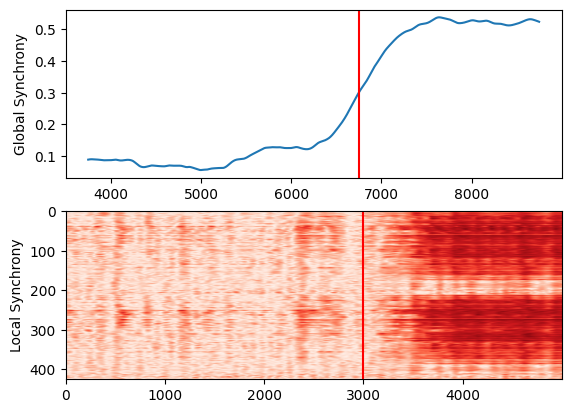

In [21]:
n=1
fig,ax = plt.subplots(2,1)
smooth = np.array(analyse.smooth(df_itr[1]))
cross = np.where(smooth>0.3)[0][0]
ax[0].plot(list(range(cross-3000,cross+2000)),smooth[cross-3000:cross+2000])
ax[0].axvline(cross,color='r')
ax[0].set_ylabel('Global Synchrony')

ax[1].imshow(df_loc.loc[1].values,cmap='Reds',aspect='auto')
ax[1].set_ylabel('Local Synchrony')
ax[1].axvline(3000,color='r')



In [ ]:
df_smooth=np.array(analyse.smooth(df_itr[3]))
# finding where it cross 0.3
# notice use nd array as this you used for local order data collection
cross=np.where(df_smooth >= 0.3)[0][0]
time_steps = list(range(0, df_smooth.shape[0]))